In [1]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from matplotlib.patches import Patch
from plotting_defaults import delete_tex_cache, set_style

from fedaugment.utils import LogParser, cd_to_git_root

cd_to_git_root()
delete_tex_cache()
set_style()

_ = pl.Config.set_tbl_rows(100)

plots_dir = Path("analysis/plots/curation")
plots_dir.mkdir(exist_ok=True, parents=True)

2026-01-28 22:23:47.252 | DEBUG    | fedaugment.utils.misc:cd_to_git_root:154 - Changed working directory to: /home/lbhm/Projects/fedaugment


In [2]:
parser = LogParser()

In [ ]:
logs = parser.parse("logs/curation/webtable/train_2025-12-27_13-13-13.log")
logs.extend(parser.parse("logs/curation/webtable/train_2025-12-29_09-49-22.log"))
logs.extend(parser.parse("logs/curation/webtable/train_2026-01-03_23-59-50.log"))
logs.extend(parser.parse("logs/curation/webtable/train_2026-01-07_12-28-42.log"))

In [4]:
data = defaultdict(dict)
summary_rows = []
for log in logs:
    if log["config"]:
        exp_name: str = log["config"]["experiment_name"]

        method = exp_name.split("-", maxsplit=1)[0][24:]
        if "pca" in exp_name:
            method += "-pca"
        if "630493" in exp_name:
            data["0.05"][method] = log["test_metrics"]["entity_stability_50"].item()
        elif "63049" in exp_name:
            data["0.005"][method] = log["test_metrics"]["entity_stability_50"].item()
        elif "12609" in exp_name:
            data["0.001"][method] = log["test_metrics"]["entity_stability_50"].item()
        elif "full" in exp_name:
            data["1"]["full"] = log["test_metrics"]["entity_stability_50"].item()

        log["test_metrics"].with_columns(pl.lit(method).alias("method"))
        summary_rows.append(
            log["test_metrics"].with_columns(pl.lit(exp_name[24:]).alias("method"))
        )

summary = (
    pl.concat(summary_rows)
    .with_columns(
        (pl.col("same_lbl_cossim_mean") / pl.col("cossim_mean")).alias("same_to_all_ratio")
    )
    .sort("entity_stability_50", descending=True)
)
summary

loss,cossim_mean,entity_stability_15,entity_stability_5,entity_stability_50,same_lbl_cossim_mean,method,same_to_all_ratio
f64,f64,f64,f64,f64,f64,str,f64
2.23578,0.00033,0.70342,0.69941,0.76756,0.98631,"""full""",2988.818182
2.39034,0.00026,0.58773,0.55905,0.67438,0.96061,"""random-mpnet-dj_adpt-k=630493""",3694.653846
2.84837,0.00028,0.42513,0.39551,0.52318,0.90098,"""random-mpnet-dj_adpt-k=63049""",3217.785714
2.58148,0.00317,0.40873,0.36442,0.49498,0.94863,"""grid-mpnet-dj_adpt-k=630493""",299.252366
2.57357,0.00302,0.40668,0.3615,0.4937,0.95007,"""grid-mpnet-dj_adpt-k=630493-pc…",314.592715
3.13042,0.00332,0.28384,0.24406,0.36736,0.87177,"""grid-mpnet-dj_adpt-k=63049""",262.581325
3.11587,0.00318,0.281,0.24157,0.36513,0.87378,"""grid-mpnet-dj_adpt-k=63049-pca…",274.773585
2.87507,0.00936,0.23904,0.19215,0.33474,0.96202,"""fft_cos-mpnet-dj_adpt-k=630493…",102.779915
2.99648,0.01543,0.21339,0.17068,0.30439,0.96074,"""fft_euc-mpnet-dj_adpt-k=630493…",62.26442


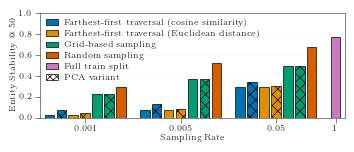

In [5]:
# Max width: 241.14 pt
fig, ax = plt.subplots(figsize=(3.525, 1.5), layout="tight")

colors = {
    "fft_cos": sns.color_palette()[0],
    "fft_euc": sns.color_palette()[1],
    "grid": sns.color_palette()[2],
    "random": sns.color_palette()[3],
    "full": sns.color_palette()[4],
}

current_x = 0
group_gap = 1
xticks: list[float] = []
xticklabels: list[str] = []

for sampling_rate, methods in sorted(data.items()):
    ordered_methods = dict(sorted(methods.items()))
    positions = [current_x + idx for idx in range(len(ordered_methods))]
    xticks.append(positions[0] + (positions[-1] - positions[0]) / 2)
    xticklabels.append(sampling_rate)

    for pos, (method_name, value) in zip(positions, ordered_methods.items(), strict=True):
        base_method = method_name.replace("-pca", "")
        color = colors[base_method]
        is_pca = method_name.endswith("-pca")
        hatch = "xxx" if is_pca else None

        bar = ax.bar(pos, value, color=color, hatch=hatch, edgecolor="black", linewidth=0.5)
    current_x += len(ordered_methods) + group_gap

legend_handles = [
    Patch(
        facecolor=colors["fft_cos"],
        edgecolor="black",
        label="Farthest-first traversal (cosine similarity)",
    ),
    Patch(
        facecolor=colors["fft_euc"],
        edgecolor="black",
        label="Farthest-first traversal (Euclidean distance)",
    ),
    Patch(facecolor=colors["grid"], edgecolor="black", label="Grid-based sampling"),
    Patch(facecolor=colors["random"], edgecolor="black", label="Random sampling"),
    Patch(facecolor=colors["full"], edgecolor="black", label="Full train split"),
    Patch(facecolor="white", edgecolor="black", hatch="xxxxx", linewidth=0.5, label="PCA variant"),
]

ax.set_xlabel("Sampling Rate")
ax.set_ylabel("Entity Stability @ 50")
ax.set_xlim(-0.75, current_x - group_gap - 0.25)
ax.set_ylim(0, 1)
ax.set_xticks(xticks, xticklabels)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(handles=legend_handles, frameon=False, ncol=1)
plt.savefig(plots_dir / "curation.pdf", pad_inches=0.00, bbox_inches="tight")
plt.show()